# Variational Autoencoder

![VAE](notebook_images/vae.jpg)

Variational Autoencoder (VAE) extends the vanilla autoencoder by introducing a probabilistic latent space. For each input, the encoder outputs the parameters (mean $\mu$ and standard deviation $\sigma$) of a normal distribution $N(\mu, \sigma^2)$, from which the latent vector $Z$ is sampled. This regularizes the latent space and typically improves generative performance. However, in terms of reconstruction quality, VAEs are not necessarily better than standard autoencoders.

**Original paper:**

Diederik P Kingma, Max Welling - Auto-Encoding Variational Bayes - https://arxiv.org/abs/1312.6114

## $\beta$ VAE

The β-VAE paper introduces a hyperparameter, β, to the loss function, which scales the weight of the KL divergence term relative to the reconstruction loss. This modification enables explicit control over the trade-off between reconstruction fidelity and the disentanglement of the latent space. 

**Paper**

Irina Higgins, Loic Matthey, Arka Pal, Christopher Burgess, Xavier Glorot, Matthew Botvinick, Shakir Mohamed, Alexander Lerchner -  beta-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework - https://openreview.net/forum?id=Sy2fzU9gl

**Further reading:**

Understanding Variational Autoencoders (VAEs) - https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73



In [127]:
import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

import torchinfo

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.patches import Rectangle

import numpy as np
import time

import os
import pathlib
from PIL import Image
import skimage
from tqdm import tqdm

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util

In [128]:
print(torch.__version__)

2.2.1+cu118


## Aux functions

In [129]:
from matplotlib import colors

def plot_scatter(x,y,targets):
    cmap = colors.ListedColormap(['black', 'darkred', 'darkblue', 
                                  'darkgreen', 'yellow', 'brown', 
                                  'purple', 'lightgreen', 'red', 'lightblue'])
    bounds=[0, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5,8.5,9.5]
    norm = colors.BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(12,10))
    plt.scatter(x, y, c = targets, cmap=cmap, s = 1, norm=norm)
    plt.colorbar()

    plt.show()


def show_preds(set1, set2, count):
  
  columns = 4
  rows = int(count*2 / columns) + 1  
  plt.figure(figsize=(count, 2 * rows))
  
  for n in range(count):
      ax = plt.subplot(rows, columns, n*2+1)
      plt.title("original")
      plt.imshow(np.transpose(set1[n].numpy(), (1,2,0)), cmap=plt.cm.gray)
      plt.axis('off')
      ax = plt.subplot(rows, columns, n*2+2)
      plt.title("reconstruction")
      plt.imshow(np.transpose(set2[n].cpu().detach().numpy(), (1,2,0)), cmap=plt.cm.gray)
      plt.axis('off')      



def train_vae(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix='model', device='cuda', beta=1.0):
    history = {'loss': [], 'val_loss': [], 'val_recon': [], 'val_kl': []}
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        start_time = time.time()
        running_loss = 0.0
        total_train_samples = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            # Handle dataset formats
            if len(batch) == 2:
                inputs, _ = batch
                targets = inputs
            elif len(batch) == 3:
                inputs, targets, _ = batch
            else:
                raise ValueError("Expected batch to have 2 or 3 elements.")
                
            inputs = inputs.to(device)
            targets = targets.to(device)
            batch_size = inputs.size(0)
            
            optimizer.zero_grad()
            
            # VAE forward pass
            outputs, mean, log_var = model(inputs)
            
            # VAE loss function requires targets, outputs, and latent parameters
            loss, rloss, klloss = loss_fn(targets, outputs, mean, log_var, beta=beta)
            
            loss.backward()
            optimizer.step()
            
            # Accumulate loss (weighted by batch size for accuracy on final incomplete batch)
            running_loss += loss.item() * batch_size
            total_train_samples += batch_size
            
        epoch_loss = running_loss / total_train_samples
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_recon_loss = 0.0
        val_kl_loss = 0.0
        total_val_samples = 0
        
        with torch.no_grad():
            for batch in val_loader:
                if len(batch) == 2:
                    inputs, _ = batch
                    targets = inputs
                elif len(batch) == 3:
                    inputs, targets, _ = batch
                else:
                    raise ValueError("Expected batch to have 2 or 3 elements.")
                    
                inputs = inputs.to(device)
                targets = targets.to(device)
                batch_size = inputs.size(0)
                
                outputs, mean, log_var = model(inputs)
                batch_loss, batch_rloss, batch_klloss = loss_fn(targets, outputs, mean, log_var, beta=beta)
                
                val_loss += batch_loss.item() * batch_size
                val_recon_loss += batch_rloss.item() * batch_size
                val_kl_loss += batch_klloss.item() * batch_size
                total_val_samples += batch_size
                
        epoch_val_loss = val_loss / total_val_samples
        epoch_val_recon = val_recon_loss / total_val_samples
        epoch_val_kl = val_kl_loss / total_val_samples
        
        # --- Scheduling and Logging ---
        old_lr = optimizer.param_groups[0]['lr']
        # Assuming scheduler is a ReduceLROnPlateau based on your step argument
        scheduler.step(epoch_val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print(f'==> Learning rate updated: {old_lr:.6f} -> {new_lr:.6f}')
            
        stop_time = time.time()
        print(f'Epoch: {epoch:03d} | Loss: {epoch_loss:.6f} | Val Loss: {epoch_val_loss:.6f} '
              f'(Recon: {epoch_val_recon:.4f}, KL: {epoch_val_kl:.4f}) | Time: {(stop_time - start_time):.4f}s')
        
        history['loss'].append(epoch_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_recon'].append(epoch_val_recon)
        history['val_kl'].append(epoch_val_kl)
        
        # --- Saving Best Model ---
        if epoch_val_loss < best_val_loss:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'history': history,
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'beta': beta
            }, f'{save_prefix}_best.pt')
            best_val_loss = epoch_val_loss
            
        # --- Early Stopping ---
        # Assuming early_stopper is a custom callable class/function
        if early_stopper(epoch_val_loss):
            print('Early stopping triggered!')
            break
            
    print('Finished Training')
    return history 


class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False

## Configuration

In [130]:
HEIGHT = 28
WIDTH = 28
NUM_CHANNELS = 1
BATCH_SIZE = 128
LATENT_SPACE_DIM = 16

MODEL_PATH = 'vae_models'

TRAIN_ONLINE = False

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


### Load and prepare MNIST dataset

In [131]:
transform = transforms.Compose(
    [transforms.ToTensor()]) 

full_dataset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_set, val_set = torch.utils.data.random_split(full_dataset, 
                                                   [train_size, val_size])

train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, 
                                           shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)

test_set = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE,
                                         shuffle=False)

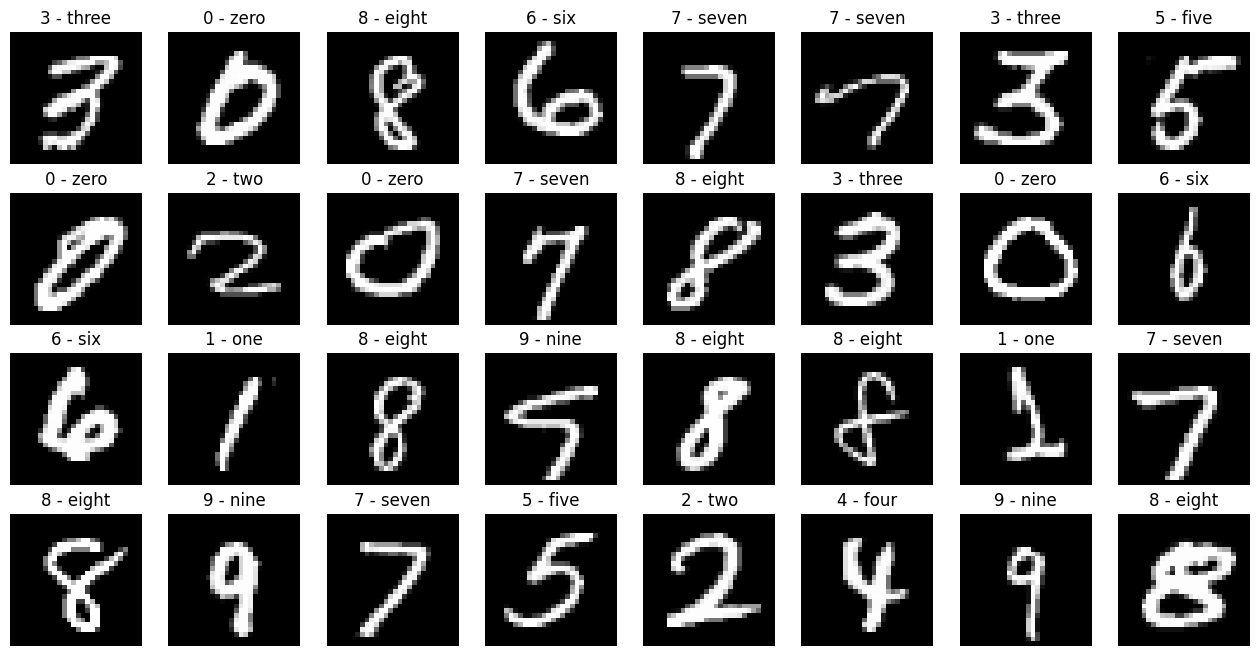

<Figure size 640x480 with 0 Axes>

In [132]:
images, targets = next(iter(train_loader))

vcpi_util.show_images(4,8, images, targets, full_dataset.classes) 

## Architecture

We are modelling a class for the encoder, and another for the decoder. These two classes will be the main building blocks of the autoencoder class, together with the sampling procedure.

In [133]:
import torch
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, latent_space_dim):
        super().__init__()

        # --- First Convolutional Block ---
        # Input: (1, 28, 28) -> Output: (32, 14, 14)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()

        # --- Second Convolutional Block ---
        # Input: (32, 14, 14) -> Output: (64, 7, 7)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()

        # --- Latent Space Projections ---
        # Flattened size: 64 channels * 7 width * 7 height = 3136
        self.fc_mean = nn.Linear(3136, latent_space_dim)
        self.fc_log_var = nn.Linear(3136, latent_space_dim)

    def forward(self, x):
        # Pass through Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        # Pass through Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)

        # Flatten the spatial dimensions into a 1D vector per batch
        x = torch.flatten(x, 1)
        
        # Calculate latent space parameters
        mean = self.fc_mean(x)
        log_var = self.fc_log_var(x)

        return mean, log_var

In [134]:
class Decoder(nn.Module):
    def __init__(self, latent_space_dim):
        super().__init__()

        # --- Latent Space Projection ---
        # Input: (latent_space_dim) -> Output: (3136)
        self.fc_latent = nn.Linear(latent_space_dim, 3136)
        
        # --- First Transposed Convolutional Block ---
        # Input: (64, 7, 7) -> Output: (32, 14, 14)
        self.convT1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, 
                                         kernel_size=3, stride=2, 
                                         padding=1, output_padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()

        # --- Second Transposed Convolutional Block (Output) ---
        # Input: (32, 14, 14) -> Output: (1, 28, 28)
        self.convT2 = nn.ConvTranspose2d(in_channels=32, out_channels=1, 
                                         kernel_size=3, stride=2, 
                                         padding=1, output_padding=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # 1. Project latent vector to a high-dimensional space
        x = self.fc_latent(x)
        
        # 2. Unflatten into 2D feature maps: (batch_size, channels, height, width)
        x = x.view(-1, 64, 7, 7)
        
        # 3. Pass through Block 1
        x = self.convT1(x)
        x = self.bn1(x)
        x = self.relu1(x)

        # 4. Pass through Block 2 (Output Block)
        x = self.convT2(x)
        x = self.sigmoid(x)

        return x

### Sampling Layer

The output of the encoder is $\hspace{0.5cm}$ $\mu$ (mean), $\log(\sigma^2)$ (log-variance)

Note:
The variance $σ^2$ must always be positive, but a neural network unit can output any real value.
For this reason, the encoder predicts $log(σ^2)$ instead of $σ^2$ directly. We can then recover the variance by exponentiation, which guarantees a positive value.





Consider: $\hspace{0.5cm}$ $\epsilon  \thicksim N(0,1)$

A sample from a normal distribution $N(\mu, \sigma^2)$ can be written as: 

$$z = \mu + \sigma \times \epsilon$$

However, we don't have $\sigma$, we have $\log(\sigma^2)$, so first we recover the standard deviation:

$$
\begin{align*}
\sigma = exp(\log(\sigma)) = \exp\left(0.5 \cdot (\log(\sigma) + \log(\sigma))\right) = \exp\left(0.5 \cdot \log(\sigma^2)\right)
\end{align*}
$$

Therefore, the latent vector is sampled as:
$$
\begin{align*}
z &= \mu + \exp\left(0.5 \cdot \log(\sigma^2)\right) \cdot \epsilon
\end{align*}
$$

This is called the **reparameterization trick**. It separates the randomness into $\epsilon$, while keeping the rest of the computation differentiable, so the model can still be trained using backpropagation.

The sampled vector $z$ is then used as the input to the decoder.


In [135]:
class VAE(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def reparameterization(self, mean, std):
        # randn_like automatically inherits the device of 'mean'
        epsilon = torch.randn_like(mean)    
        z = mean + std * epsilon  
        return z  

    def forward(self, x):
        mean, log_var = self.encoder(x)
        
        # Convert log variance to standard deviation
        std = torch.exp(0.5 * log_var)
        
        # Best practice: deterministic latents during evaluation
        if self.training:
            z = self.reparameterization(mean, std)
        else:
            z = mean 
            
        output = self.decoder(z)

        return output, mean, log_var

In [136]:
encoder = Encoder(LATENT_SPACE_DIM)
decoder = Decoder(LATENT_SPACE_DIM)

model = VAE(encoder=encoder, decoder=decoder)
model.to(device)

torchinfo.summary(
    model, 
    input_size=(BATCH_SIZE, 1, 28, 28), 
    col_names=["kernel_size", "input_size", "output_size"])



Layer (type:depth-idx)                   Kernel Shape              Input Shape               Output Shape
VAE                                      --                        [128, 1, 28, 28]          [128, 1, 28, 28]
├─Encoder: 1-1                           --                        [128, 1, 28, 28]          [128, 16]
│    └─Conv2d: 2-1                       [3, 3]                    [128, 1, 28, 28]          [128, 32, 14, 14]
│    └─BatchNorm2d: 2-2                  --                        [128, 32, 14, 14]         [128, 32, 14, 14]
│    └─ReLU: 2-3                         --                        [128, 32, 14, 14]         [128, 32, 14, 14]
│    └─Conv2d: 2-4                       [3, 3]                    [128, 32, 14, 14]         [128, 64, 7, 7]
│    └─BatchNorm2d: 2-5                  --                        [128, 64, 7, 7]           [128, 64, 7, 7]
│    └─ReLU: 2-6                         --                        [128, 64, 7, 7]           [128, 64, 7, 7]
│    └─Linear: 2-7   

## Loss function

The Variational Autoencoder (VAE) loss function has two components: 

- **Reconstruction loss** - this term is similar to the loss used in a regular autoencoder. It measures the discrepancy between the obtained output and the desired output, and its purpose is to encourage faithful reconstruction of the input data


<div align="center">

$\text{Reconstruction loss} = \frac{1}{B} \sum_{i=1}^{B} \left( \sum_{j=1}^{D} - \left[ x_{ij} \log(\hat{x}_{ij}) + (1 - x_{ij}) \log(1 - \hat{x}_{ij}) \right] \right)$
</div>

Where $B$ is the batch size, and $D$ is the number of pixels ($28 \times 28 = 784$).

- **KL loss**: this term is the Kullback-Leibler (KL) divergence between the learned distribution and a known prior distribution (typically a standard normal distribution). For the KL Loss we consider the prior to be a Normal distribution with $\mu = 0$ and $\sigma = 1$. We sum the divergence across all dimensions ($L$) of the latent space.

<div align="center">

$\text{KL loss} = \frac{1}{B} \sum_{i=1}^{B} \left( \sum_{k=1}^{L} -0.5 \times \left( 1 + \log(\sigma_{ik}^2) - \mu_{ik}^2 - e^{\log(\sigma_{ik}^2)} \right) \right)$
</div>

Where $B$ is the batch size, and $L$ is the latent space dimension (e.g., 2).

Total VAE Loss:
<div align="center">

$\text{Total Loss = Reconstruction loss + KL loss}$</p>
</div>

In $\beta$-VAE the loss function is:
<div align="center">

$\text{Total Loss = Reconstruction loss} + \beta \times \text{KL loss}$</p>
</div>

Setting β greater than 1, can encourage more disentangled or interpretable latent factors, often at the expense of reconstruction quality. 

### Note regarding the divergence function

The KL divergence is the standard regularization term used in the original VAE formulation. Later work explored replacing it with other divergences or distribution distances:

- **Jensen-Shannon Divergence** — the divergence implicitly minimized by GANs (Goodfellow et al., 2014 [PDF]( https://arxiv.org/abs/1406.2661));

- **Maximum Mean Discrepancy** —  used in the MMD-based variant of InfoVAE (Zhao et al., 2017 [PDF](https://arxiv.org/abs/1706.02262)), commonly referred to in later literature as MMD-VAE (e.g., Zhang, 2019 [PDF](https://www.biorxiv.org/content/10.1101/613414v2)) ;

- **Wasserstein distance** — used in WAE (Tolstikhin et al., 2018 [PDF](https://arxiv.org/abs/1711.01558));

- **Skew-geometric Jensen-Shannon divergence** — used in JSG-VAE (Deasy et al., 2020 [PDF](https://arxiv.org/abs/2006.10599)), shown to outperform standard KL on several benchmarks.



In [137]:
def loss_function(targets, outputs, mean, log_var, beta=1.0):
    mse = torch.nn.functional.mse_loss(outputs, targets, reduction='none')
    recon_loss = mse.view(mse.size(0), -1).sum(dim=1).mean()
    
    kld_element = -0.5 * (1 + log_var - mean.pow(2) - log_var.exp())
    kld = kld_element.sum(dim=1).mean()

    total_loss = recon_loss + beta * kld
    return total_loss, recon_loss, kld


### Implementation Note: Scaling the VAE Loss
When implementing the VAE loss in PyTorch, one must be extremely careful with how the averages are computed.

In a standard Autoencoder, it is common to use reduction='mean' to average the error across all pixels. Do not do this in a VAE.

The VAE loss consists of two competing forces that must be correctly balanced: the Reconstruction Loss and the KL Divergence penalty. Averaging the reconstruction error across all pixels, the value is divide by the image size (e.g., 784 for MNIST). Meanwhile, the KL Divergence is only distributed across a tiny latent space (e.g., 2 dimensions).

This scaling mismatch makes the KL penalty hundreds of times stronger than the reconstruction loss. To minimize this massive penalty, the network will completely ignore the input image, force the latent space into random noise ($\mu=0, \sigma=1$), and output a constant gray blob. This famous failure mode is known as Latent Space Collapse (or KL Vanishing).

Best Practice: Always sum the loss across the feature dimensions (all 784 pixels for reconstruction, all 2 latent dimensions for KL). Only apply the mean across the batch dimension (dim=0). This perfectly preserves the mathematical balance between the two loss terms while keeping your learning rate stable regardless of your batch size.

## Training

In [138]:
if TRAIN_ONLINE:
    
    EPOCHS = 100

    latent_spaces = [2, 16]

    for ls in latent_spaces:

        encoder = Encoder(LATENT_SPACE_DIM)
        decoder = Decoder(LATENT_SPACE_DIM)

        model = VAE(encoder=encoder, decoder=decoder)
        model.to(device)


        LATENT_SPACE_DIM = ls

        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, 
                                            mode='min', factor = 0.1, patience=3)
        early_stop = Early_Stopping(9)

        save_prefix=f'vae_models/vae_{LATENT_SPACE_DIM}'
        
        # Train the model
        model = train_vae(
            model=model,
            train_loader=train_loader,
            val_loader=test_loader,      # Using test_loader as validation
            epochs=EPOCHS,
            loss_fn=loss_function,
            optimizer=opt,
            scheduler=scheduler,
            early_stopper=early_stop,
            save_prefix=f'vae_models/vae_{LATENT_SPACE_DIM}',
            beta = 1
        )



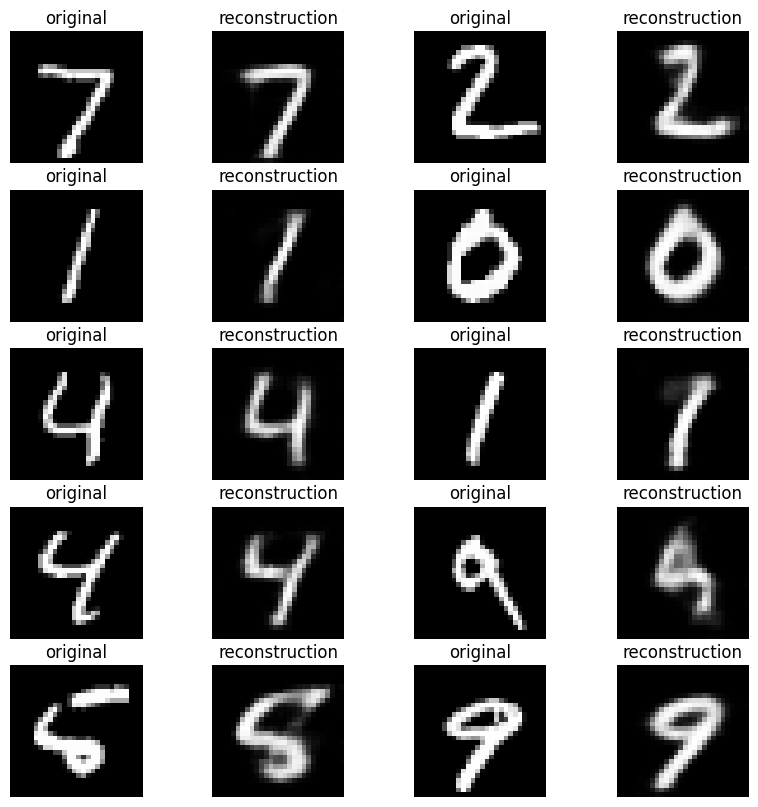

In [139]:
LATENT_SPACE_DIM = 16

reload = torch.load(f'{MODEL_PATH}/vae_{LATENT_SPACE_DIM}_best.pt')

model = VAE(Encoder(LATENT_SPACE_DIM), Decoder(LATENT_SPACE_DIM))
model.load_state_dict(reload['model_state_dict'])
model.to(device)

i, _ = next(iter(test_loader))
recon,_,_ = model(i.to(device))
    
show_preds(i, recon, 10)

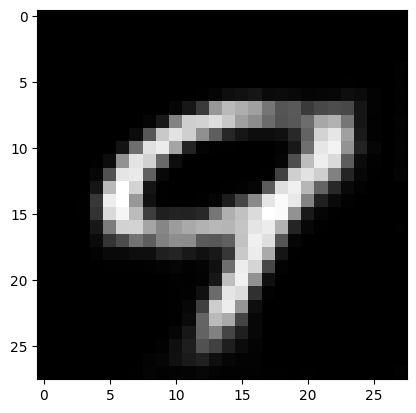

In [140]:
pred = model.decoder(torch.randn(LATENT_SPACE_DIM).to(device))
plt.imshow(np.transpose(pred[0].cpu().detach().numpy(), (1,2,0)), cmap=plt.cm.gray)

## Displaying Latent Space

Unlike a regular autoencoder, a VAE does not encode each input as a single point. Instead, it encodes each input as a Gaussian distribution characterized by a mean $\mu$ and a variance $\sigma^2$. The mean plot shows the location of each sample in latent space, while the variance plot shows how uncertain or spread out that representation is. 

The mean answers “where is the sample?”, whereas the variance answers “how confident is the model about that location?

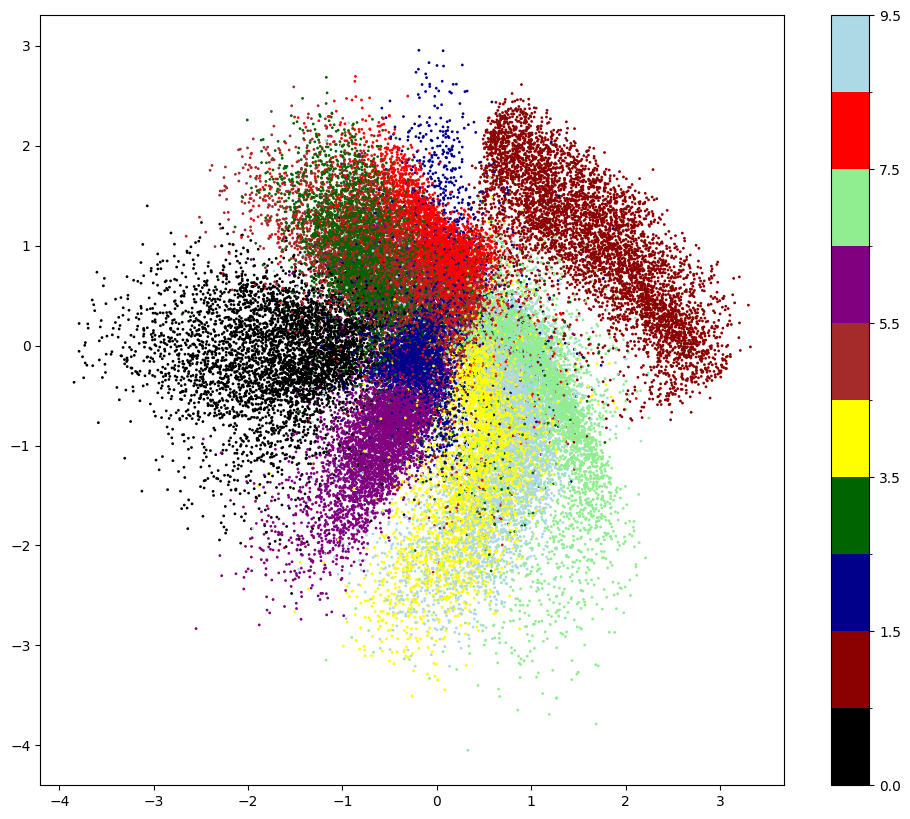

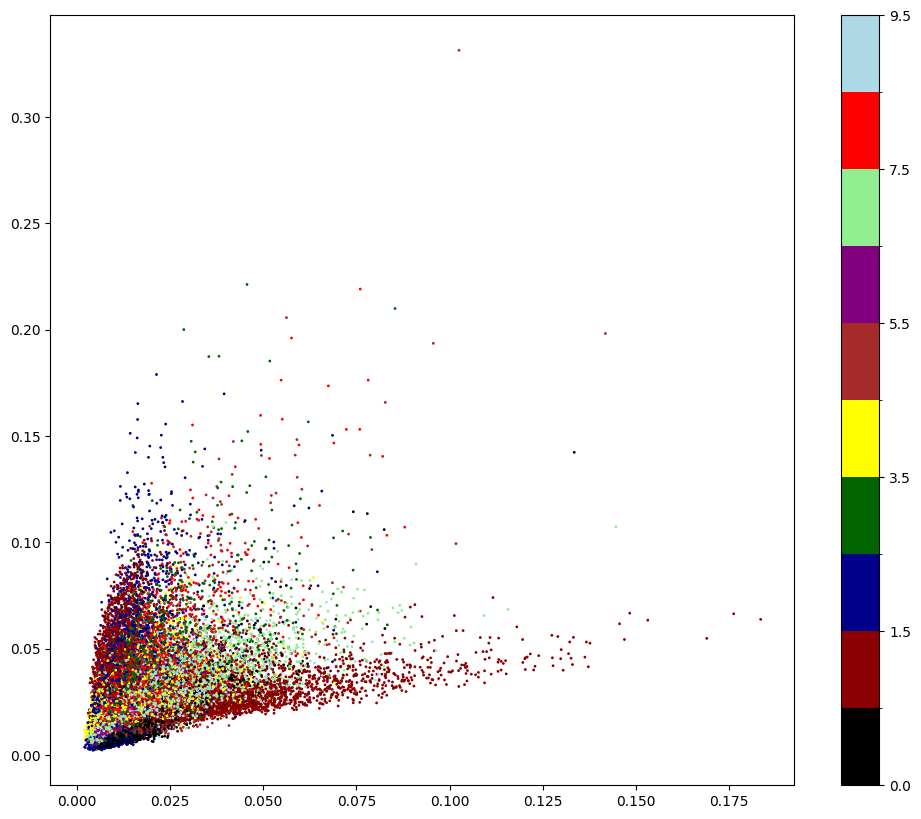

In [141]:
import math

LATENT_SPACE_DIM = 2
reload = torch.load(f'{MODEL_PATH}/vae_{LATENT_SPACE_DIM}_best.pt')

model = VAE(Encoder(LATENT_SPACE_DIM), Decoder(LATENT_SPACE_DIM))
model.load_state_dict(reload['model_state_dict'])
model.to(device)

encoded_mean = []
encoded_log_var = []
targets = []
for i,t in train_loader:
    mean, log_var = model.encoder(i.to(device))
    encoded_mean.extend(mean.cpu().detach().numpy())  
    encoded_log_var.extend(log_var.cpu().detach().numpy())
    targets.extend(t)

x = [m[0] for m in encoded_mean]
y = [m[1] for m in encoded_mean]

plot_scatter(x,y,targets)

x = [math.exp(m[0]) for m in encoded_log_var]
y = [math.exp(m[1]) for m in encoded_log_var]

plot_scatter(x,y,targets)

## Sampling Interval Based on the Empirical Rule

The **empirical rule** (also known as the 68-95-99.7 rule) describes how data is distributed in a normal distribution:

- Approximately **68%** of values lie within **one standard deviation** of the mean.
- Approximately **95%** lie within **two standard deviations**.
- Approximately **99.7%** lie within **three standard deviations**.



Intervals for a Standard Normal Distribution ($N(0,1)$)

| Coverage | Interval    |
|----------|-------------|
| 68%      | [-1, 1]     |
| 95%      | [-2, 2]     |
| 99.7%    | [-3, 3]     |

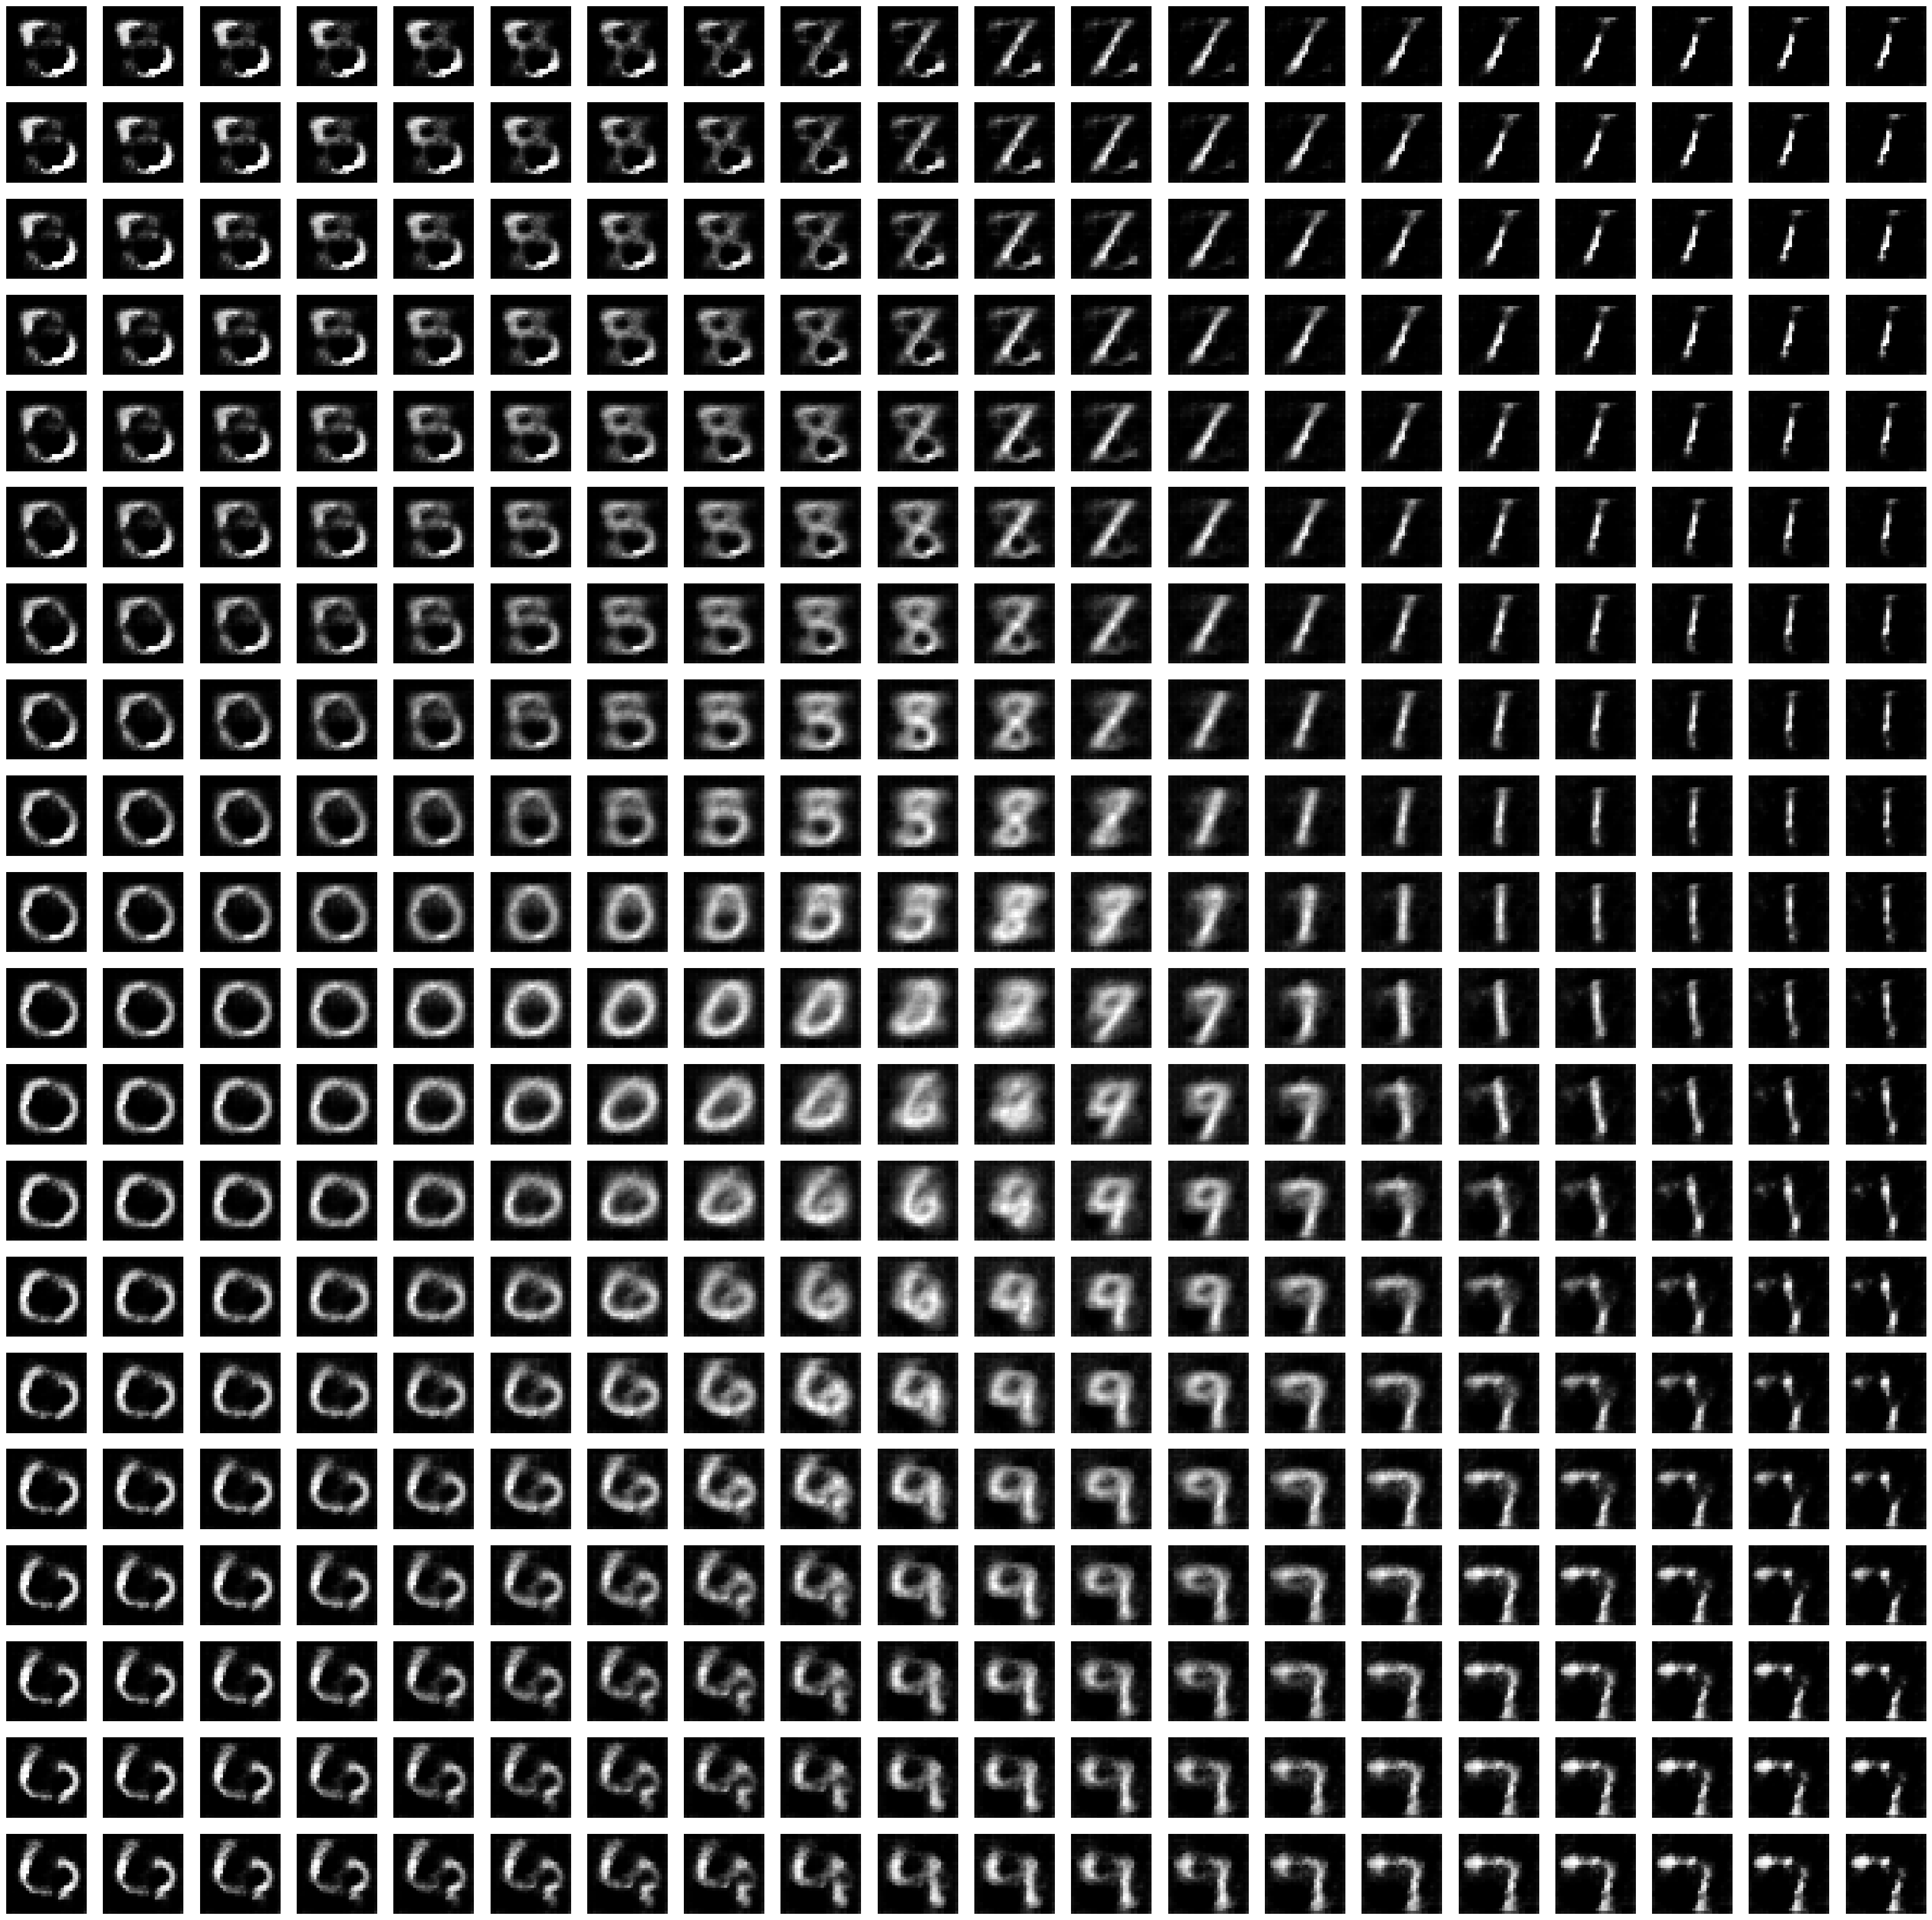

<Figure size 640x480 with 0 Axes>

In [142]:
if LATENT_SPACE_DIM == 2:
    limit = 5
    steps = 20

    step = (2.0 * limit) / steps

    vector_generation = [[-limit + j*step, limit - i*step] 
                                for i in range(steps) for j in range(steps)]

    predictions = model.decoder(torch.Tensor(vector_generation).to(device))

    vcpi_util.show_predicted_images(steps, steps, predictions.cpu().detach(), 10)

# VAEs vs. AEs

In this section we evaluate the differences between the AE and VAE on a series of tests. As MNIST is a very simple dataset, these tests were performed on CelebA, a dataset of face images that also includes binary attribute labels, allowing us to test attribute manipulation.

The first test was about the reconstruction ability. The results show both models have similar reconstruction capabilities, with the VAE producing slightly blurrier images. This is expected as the VAE optimizes a combined objective that balances reconstruction quality against the KL divergence between the learned latent distribution and the prior $\mathcal{N}(0, \mathbf{I})$. This trade-off prevents the VAE from dedicating all of its capacity to reconstruction, which is why the AE can be sharper.

The test losses, computed using the same MSE-based reconstruction loss for both models, confirm this. The VAE reconstruction loss (784.68) is slightly higher than the AE reconstruction loss (734.43), reflecting the regularization cost imposed by the KL term. The KL loss of 350.43 shows that the VAE is paying a substantial price to keep the latent distribution close to the prior — a cost that the AE never incurs

| | Value |
|---|---|
| AE Reconstruction Loss | 734.43 |
| VAE Reconstruction Loss | 784.68 |
| VAE KL Loss | 350.43 |
| VAE Total Loss | 1135.11 |

![](notebook_images/vae_vs_ae_recon.png)

The next test was random sampling from latent space. Both models were given the same set of random latent space sampled from $\mathcal{N}(0, \mathbf{I})$ to generate an output. While the AE failed to generate any meaningful image, the VAE produced "recognisable" faces, although with some blurriness and imperfections.

 The clearest advantage of the VAE is in random sampling from $\mathcal{N}(0, \mathbf{I})$. The VAE produces "faces" because its latent space was explicitly regularized to match a known prior distribution, whereas the AE does not guarantee this property. The latent space of an AE is unbounded, making it difficult to sample based on randomness alone.

![](notebook_images/vae_vs_ae_ae_random_sample.png)

![](notebook_images/vae_vs_ae_vae_random_sample.png)

The third test examined the stability of each model under latent perturbations. Starting from the encoded representation of a real image, Gaussian noise of increasing scale was added to the latent vector before decoding.

The VAE shows a gradual drift in identity as the perturbation scale increases. At small scales the decoded image is nearly identical to the original, but at larger scales the latent code moves into regions associated with different faces, and the output begins to resemble a different identity. This is a direct consequence of the KL regularization: all latent codes are compressed into a compact region near the origin to match the prior $\mathcal{N}(0, \mathbf{I})$, so a perturbation of fixed absolute magnitude represents a larger relative displacement in the VAE latent space than in the AE latent space.

The AE, by contrast, remains anchored to the same identity across all perturbation scales. Its latent space is unconstrained and spreads across a much larger region, so the same absolute perturbation is proportionally smaller and the decoder remains in a familiar neighbourhood.

This result and the random sampling test are two sides of the same coin. The compactness that makes the VAE latent space sampleable from $\mathcal{N}(0, \mathbf{I})$ is also what causes it to drift under perturbation. The AE's larger and less structured latent space is locally more stable, but cannot be reliably sampled from a fixed prior.

![](notebook_images/vae_vs_ae_ae_latent_perturbation.png)
![](notebook_images/vae_vs_ae_vae_latent_perturbation.png)

The fourth test focused on latent space interpolation. Given two images, their latent space is recovered and the models are asked to produce images whose latent space interpolates linearly between the two. The results show similar interpolation capabilities for both models. This suggest that with a large enough latent space and a high-capacity architecture, both models tend to learn a locally smooth latent manifold, which is sufficient for reasonable interpolation even without explicit regularization.

![](notebook_images/vae_vs_ae_ae_interp.png)
![](notebook_images/vae_vs_ae_vae_interp.png)


The final test addresses attribute manipulation. In this experiment, we test whether a semantic facial attribute can be modified by moving in a specific direction in latent space. 

We first choose an attribute (Arched_Eyebrows) and compute an attribute vector by subtracting the mean latent code of images without the attribute from the mean latent code of images with the attribute. We then encode a test image, add scaled versions of this direction to its latent code, and decode the result. By varying $\alpha$, we can observe whether moving along that latent direction gradually removes or enhances the chosen attribute. This procedure is applied to both the AE and the VAE to compare how well their latent spaces support semantic editing.

The results show that both the AE and the VAE successfully manipulate the Arched_Eyebrows attribute. As $\alpha$ increases from $-4$ to $4$, the eyebrows become visibly more arched. Interestingly, both models also simultaneously change the perceived gender and makeup of the face. This occurs because the vector $\mu_1 - \mu_0$ captures all features correlated with arched eyebrows in the CelebA dataset, demonstrating that the learned attribute direction is entangled.

The AE performs this manipulation just as well as the VAE. With a large 256-dimensional latent space, the AE has enough capacity to naturally organize its representations such that semantic directions emerge, even without the KL regularization of the VAE. Once again, the key distinction between the models does not lie in deterministic latent arithmetic, but in the VAE's ability to sample novel faces reliably from the prior distribution $\mathcal{N}(0, \mathbf{I})$.

![](notebook_images/vae_vs_ae_ae_attribute_inter.png)

![](notebook_images/vae_vs_ae_vae_attribute_inter.png)


## Conclusion

This series of experiments compared a standard Autoencoder (AE) and a Variational Autoencoder (VAE) trained on the CelebA dataset using a high-capacity, 256-dimensional latent space. The results highlight the fundamental trade-offs between deterministic compression and probabilistic generative modeling.

When evaluated on reconstruction quality, both models produce acceptable results—though undeniably blurry by modern generative standards—with the AE producing slightly sharper images. This occurs because the AE is optimized purely to minimize reconstruction error, whereas the VAE must balance reconstruction against the KL divergence penalty that regularizes its latent space.

Surprisingly, the models also demonstrated comparable capabilities in latent space interpolation and attribute manipulation. With a large enough latent dimension, even the unconstrained AE naturally organizes its representations well enough to support semantic vector arithmetic. Both models successfully captured entangled semantic directions (such as adding arched eyebrows along with makeup and feminine features) and produced smooth transitions between real encoded images.

The differences between the architectures emerged clearly in the latent perturbation and random sampling tests. Because the VAE compresses its representations to match the prior $\mathcal{N}(0, \mathbf{I})$, its latent space is densely packed. Consequently, adding scaled noise to a VAE latent vector causes the image to drift into different identities. The AE's unconstrained latent space is much larger, making it locally more stable to perturbations of the same absolute scale.

However, this same compact regularization is what gives the VAE its defining advantage: generative capability. When sampling random vectors from the prior $\mathcal{N}(0, \mathbf{I})$, the VAE successfully generates coherent, novel faces. The AE fails completely at this task, generating incoherent artifacts, because its latent space is not mapped to any known probability distribution.

At least in these experiments, the results show that the VAE's advantage does not necessarily lie in better reconstructions or superior attribute editing, particularly when using high-capacity networks. Instead, the VAE's true power is theoretical and generative: by forcing the latent space to follow a standard normal distribution, it provides a principled way to sample and generate entirely new data from scratch.